In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Load the historical Boston housing dataset
# Change the filename string to match your uploaded asset
data = pd.read_csv('data/boston.csv')
print(f"Dataset Shape Dimensions: {data.shape}")

# 2. Inspect column features and quick statistical metrics
print(data.info())
data.describe()

Dataset Shape Dimensions: (506, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   CRIM        506 non-null    float64
 2   ZN          506 non-null    float64
 3   INDUS       506 non-null    float64
 4   CHAS        506 non-null    float64
 5   NOX         506 non-null    float64
 6   RM          506 non-null    float64
 7   AGE         506 non-null    float64
 8   DIS         506 non-null    float64
 9   RAD         506 non-null    float64
 10  TAX         506 non-null    float64
 11  PTRATIO     506 non-null    float64
 12  B           506 non-null    float64
 13  LSTAT       506 non-null    float64
 14  PRICE       506 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 59.4 KB
None


,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


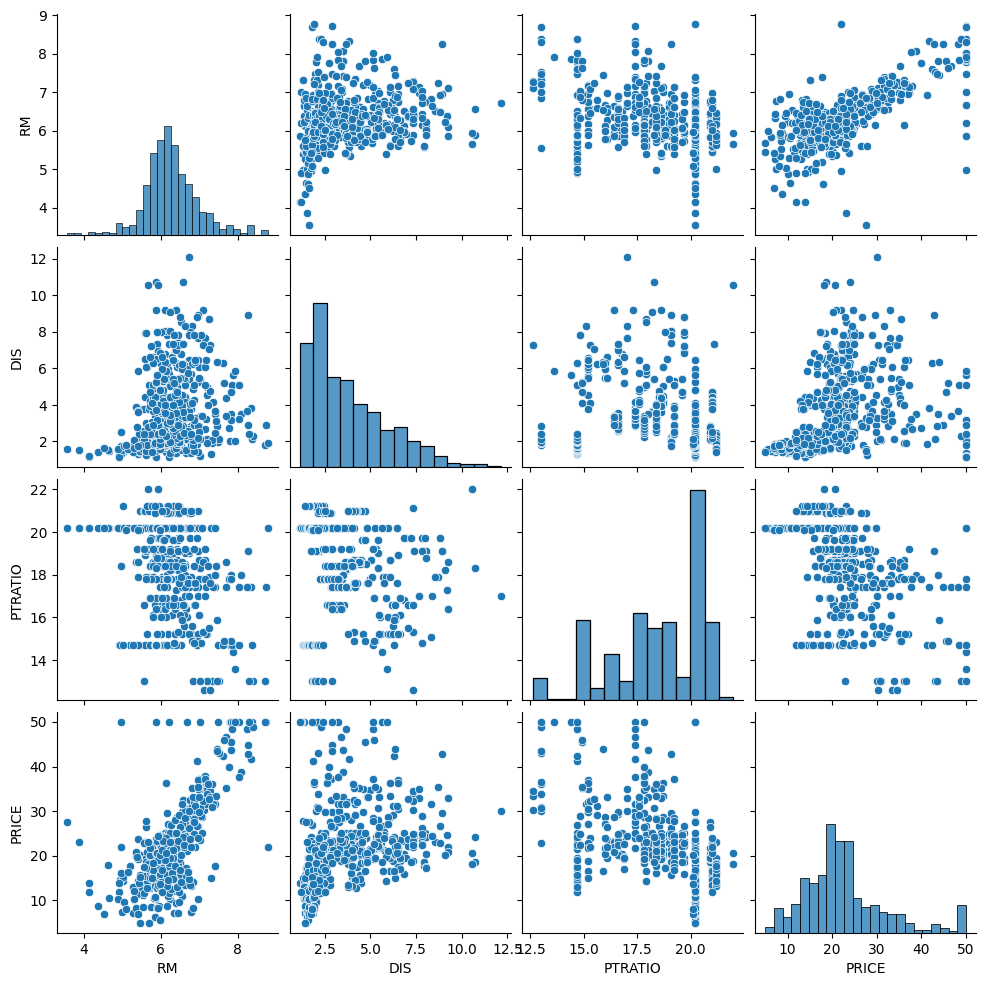

In [3]:
# Render a quick correlation matrix grid (Note: this can take a moment to draw!)
sns.pairplot(data[['RM', 'DIS', 'PTRATIO', 'PRICE']])
plt.show()

In [4]:
# 1. Separate target label prices (y) from independent architectural input features (X)
X = data.drop('PRICE', axis=1)
y = data['PRICE']

# 2. Execute a stratified train-test split validation cut
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% reserved for validation testing
    random_state=10      # Assures reproducibility
)

print(f"Training Matrix Shape: {X_train.shape}") # 80% of data
print(f"Validation Matrix Shape: {X_test.shape}") # 20% of data

Training Matrix Shape: (404, 14)
Validation Matrix Shape: (102, 14)


In [5]:
# 1. Initialize and train the Multivariable Regression Engine
model = LinearRegression()
model.fit(X_train, y_train)

# 2. Evaluate model metrics across both independent sets
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print(f"Training R-Squared Score:   {train_r2:.3f}")
print(f"Validation R-Squared Score: {test_r2:.3f}")

# 3. View calculated weights per variable
coefficients = pd.DataFrame(data=model.coef_, index=X.columns, columns=['Coefficient'])
print("\nModel Feature Weights:")
print(coefficients)

Training R-Squared Score:   0.751
Validation R-Squared Score: 0.672

Model Feature Weights:
            Coefficient
Unnamed: 0    -0.002411
CRIM          -0.129545
ZN             0.064533
INDUS         -0.007466
CHAS           1.986908
NOX          -16.248233
RM             3.136214
AGE            0.014160
DIS           -1.498416
RAD            0.320774
TAX           -0.011161
PTRATIO       -0.826613
B              0.011484
LSTAT         -0.581550


<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_5611/463030985.py:9: SyntaxWarning: invalid escape sequence '\h'
  plt.title('Actual vs Predicted Boston House Prices: $y_i$ vs $\hat{y}_i$', fontsize=14)
/tmp/ipykernel_5611/463030985.py:11: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Predicted prices ($000s) $\hat{y}_i$', fontsize=12)


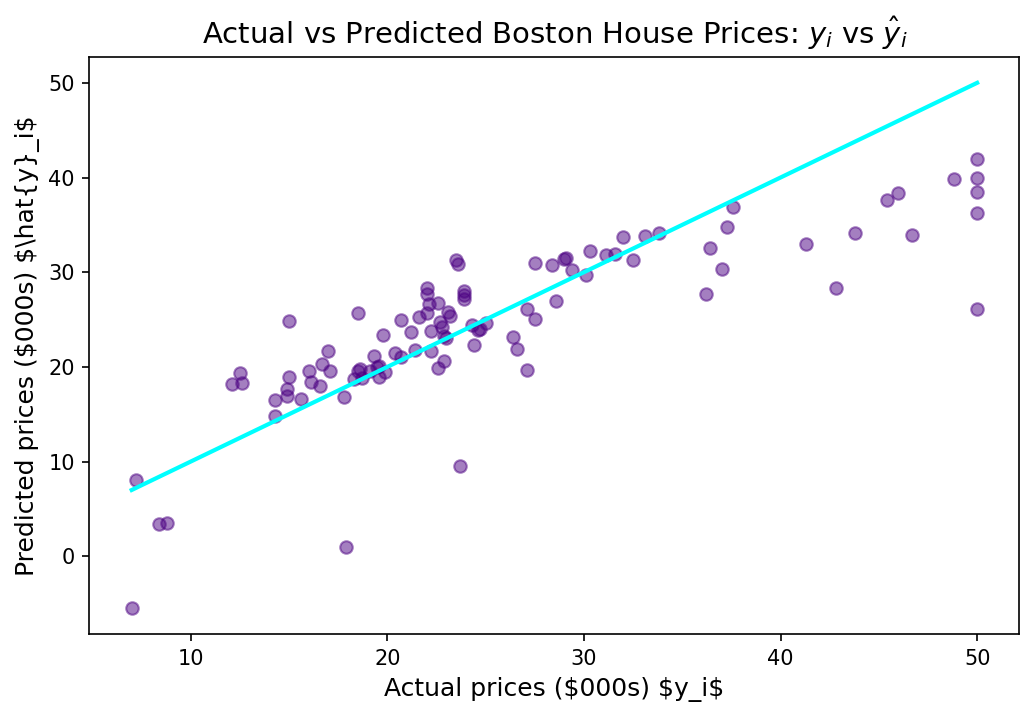

In [6]:
# 1. Predict valuations across the validation testing slice
predictions = model.predict(X_test)

# 2. Render Actual vs Predicted Valuations
plt.figure(figsize=(8, 5), dpi=150)
plt.scatter(y_test, predictions, color='indigo', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='cyan', linewidth=2)

plt.title('Actual vs Predicted Boston House Prices: $y_i$ vs $\hat{y}_i$', fontsize=14)
plt.xlabel('Actual prices ($000s) $y_i$', fontsize=12)
plt.ylabel('Predicted prices ($000s) $\hat{y}_i$', fontsize=12)
plt.show()

In [7]:
# 1. Transform targets using natural logarithm broadcasting
y_log = np.log(data['PRICE'])

# 2. Re-slice the log targets using our split framework
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=10)

# 3. Retrain the log-linear pipeline model
log_model = LinearRegression()
log_model.fit(X_train_log, y_train_log)

print(f"New Log-Transform Training R2:   {log_model.score(X_train_log, y_train_log):.3f}")
print(f"New Log-Transform Validation R2: {log_model.score(X_test_log, y_test_log):.3f}")

New Log-Transform Training R2:   0.794
New Log-Transform Validation R2: 0.746


In [10]:
# Double-check that PRICE is being dropped completely
X = data.drop('PRICE', axis=1)
y = np.log(data['PRICE']) # Target column converted to log values

In [11]:
print(f"Number of training columns: {X.shape[1]}")

Number of training columns: 14


In [13]:
# 1. Added a 0 at the start to bring the count to 14
example_house_features = [[0, 0.1, 10.0, 5.0, 0, 0.4, 6.5, 50.0, 4.0, 4, 300, 15.0, 390, 7.5]]

# 2. Predict log price valuation
predicted_log_price = log_model.predict(example_house_features)[0]

# 3. Inverse transform log values back to real-world dollar values using np.exp()
actual_dollar_valuation = np.exp(predicted_log_price) * 1000

print(f"=== REAL ESTATE VALUATION REPORT ===")
print(f"Log Predicted Output: {predicted_log_price:.4f}")
print(f"Estimated Market Price: ${actual_dollar_valuation:,.2f}")

=== REAL ESTATE VALUATION REPORT ===
Log Predicted Output: 3.4570
Estimated Market Price: $31,720.34


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
